# SSP-DINO compatibility  playground
Exploring effects of L2 normalization vs. ssp-normalization over frequency spectrum. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.datasets import CIFAR10

Using images from CIFAR dataset to get toy DINO embeddings.

In [20]:
transform = T.Compose([
    T.Resize(224), T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])
dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino_model.eval();

Using cache found in /Users/sarkaliskova/.cache/torch/hub/facebookresearch_dinov2_main


In [26]:
embeddings = []
dataset = CIFAR10(root='.', train=False, download=True, transform=transform)
for i in range(10):
    img, _ = dataset[i]
    with torch.no_grad():
        e = dino_model(img.unsqueeze(0)).cpu().numpy().flatten()
    embeddings.append(e)


Files already downloaded and verified


In [27]:
SSP_DIM = 384 
np.random.seed(1)

# L2 normalize 
dinos_L2 = []
for i in range(10):
    dinos_L2.append(embeddings[i] / np.linalg.norm(embeddings[i]))
    
# SSP unitary normalize
def to_unitary_ssp(vec, n=None):
    v = vec.astype(np.float64).ravel()
    if n is None: n = v.size
    V = np.fft.rfft(v, n=n)
    V_unit = V / (np.abs(V) + 1e-9)        # unit magnitude per bin
    u = np.fft.irfft(V_unit, n=n)
    u /= (np.linalg.norm(u) + 1e-9)         # optional
    return u

dinos_sspunitary = []
for i in range(10):
    dinos_sspunitary.append(to_unitary_ssp(embeddings[i]))

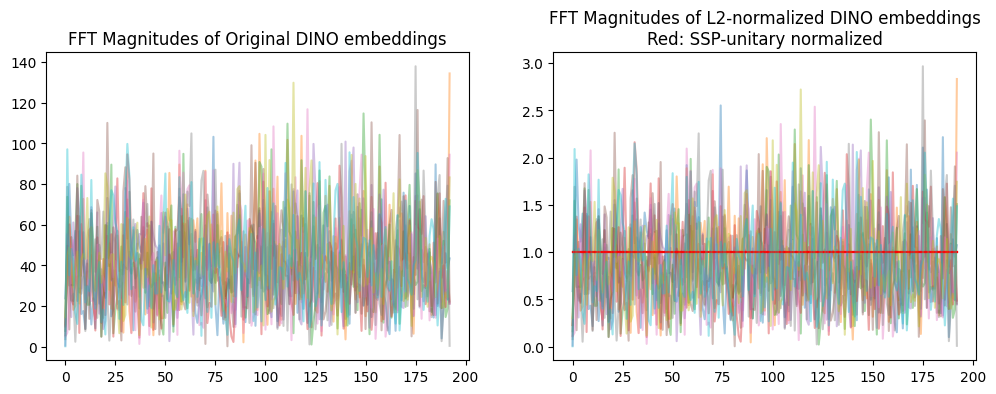

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(10):
    axes[0].plot(np.abs(np.fft.rfft(embeddings[i])), alpha=0.4)
    
axes[0].set_title("FFT Magnitudes of Original DINO embeddings")
for i in range(10):
    axes[1].plot(np.abs(np.fft.rfft(dinos_L2[i])), alpha=0.4)
    axes[1].plot(np.abs(np.fft.rfft(dinos_sspunitary[i])), 'r', alpha=0.4)

axes[1].set_title("FFT Magnitudes of L2-normalized DINO embeddings\nRed: SSP-unitary normalized");
plt.show()


In [61]:
import sspspace

[x,y] = [1.0, 2.0]  # example position
coord_encoder = sspspace.RandomSSPSpace(domain_dim=2, ssp_dim=SSP_DIM)
ssp_key = coord_encoder.encode([[x, y]]) # ssp position key

def bind(a, b): 
    return np.fft.irfft(np.fft.rfft(a) * np.fft.rfft(b))

b_L2  = bind(dinos_L2[0], ssp_key)
b_ssp = bind(dinos_sspunitary[0], ssp_key)

print("Norms after binding:")
print("  L2-normalized:", np.linalg.norm(b_L2))
print("  SSP-unitary   :", np.linalg.norm(b_ssp)) 

# With the current setup, L2-normalized binding results in a decrease in norm, while SSP-unitary binding maintains a norm close to 1.

Norms after binding:
  L2-normalized: 1.0000000422498605
  SSP-unitary   : 0.999999999


## Exploring similarity of DINO embeddings 
As DINO embedings don't originate from the SSP space, they can be correlated (not almost-orthogonal as SSP) $\rightarrow$ more similar to each other. Non-orthogonality of DINO embeddings can affect working memory performance by increasing interference during binding and memory retrieval. (Storing multiple patches in the same memory might result in overlap of the features. $\rightarrow$ Lower capacity of the memory.).   

**DINO embeddings:** semantic richness $\rightarrow$ high representational quality;   
increased interference compared to random SSP vectors. 

Binding the DINO patches with SSP positions should orthogonalize the vectors: cos similarity $\rightarrow 0$. Unless we need to unbind (DINO-patch, SSP-position, SSP-rotation) precisely, it should be ok.

/var/folders/_f/thnl7v_97zg0x6p6fkjz5kf40000gn/T/ipykernel_50288/4192708047.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


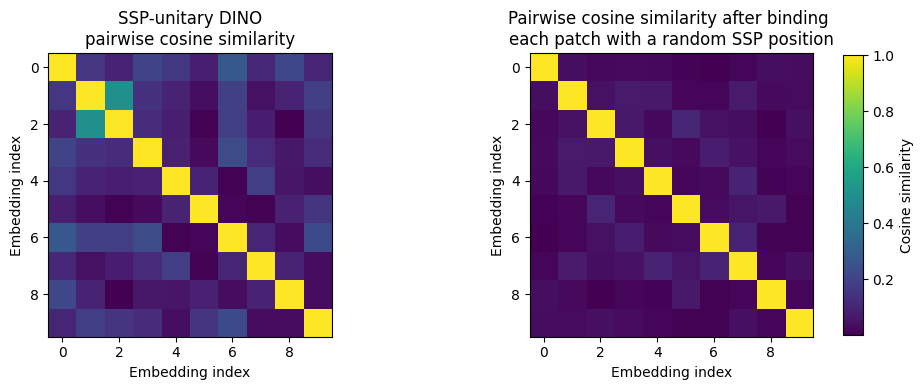

In [68]:
def cos_sim_matrix(X):
    Xn = X / (np.linalg.norm(X, axis=-1, keepdims=True) + 1e-9)
    return Xn @ Xn.T

def rand_unitary_key(D):
    r = np.random.randn(D)
    return to_unitary_ssp(r)

N, D = np.array(embeddings).shape
np.random.seed(0)

emb_unit = np.stack([to_unitary_ssp(e) for e in embeddings], axis=0)
S_unit = cos_sim_matrix(emb_unit)

# Make N independent unitary SSP keys (positions)
keys = np.stack([rand_unitary_key(D) for _ in range(N)], axis=0)

# Bind each patch DINO with its own position key
bound = np.stack([bind(emb_unit[i], keys[i]) for i in range(N)], axis=0)
S_bound = cos_sim_matrix(bound) # evaluate similarity to other vectors

# plot cosine similarity matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(np.abs(S_unit), cmap="viridis", vmax=1)
axes[0].set_title("SSP-unitary DINO\npairwise cosine similarity")
axes[0].set_xlabel("Embedding index")
axes[0].set_ylabel("Embedding index")

im1 = axes[1].imshow(np.abs(S_bound), cmap="viridis",  vmax=1)
axes[1].set_title("Pairwise cosine similarity after binding \neach patch with a random SSP position")
axes[1].set_xlabel("Embedding index")
axes[1].set_ylabel("Embedding index")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im1, cax=cbar_ax, label="Cosine similarity")
plt.tight_layout()
plt.show()